# AnemoScan: Ai - Based Early Detection Of Anemia From Nail & Conjunctiva Images
## Block 4 - Explainable AI (XAI) using Grad-CAM - Conjunctiva and Nails Dataset
- In this notebook, we apply Grad-CAM (Gradient-weighted Class Activation Mapping) to visualize which regions of the images contribute most to the model's predictions.

- This is especially important in medical AI systems, where interpretability helps build trust and ensures that the model is making decisions based on relevant physiological features.

We apply Grad-CAM on both:
- Conjunctiva dataset
- Nails dataset

to compare how each model makes decisions.

## 1. Import Required Libraries
- In this section, we import all necessary libraries for model loading, image processing, and applying Explainable AI (XAI) techniques such as Grad-CAM for visualization.

In [3]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

## 2. Remove Black Borders
- In this section, a preprocessing function is applied to detect and remove black borders from images by converting them to grayscale, applying thresholding to identify non-black regions, and cropping the image around the detected area with slight padding to preserve important details.

In [5]:
def remove_black_borders(image, threshold = 10):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        
        padding = 5
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(image.shape[1] - x, w + 2 * padding)
        h = min(image.shape[0] - y, h + 2 * padding)
        return image[y : y + h, x : x + w]
    return image  # fallback

## 3. Grad-CAM Implementation

- In this section, we implement the Grad-CAM (Gradient-weighted Class Activation Mapping) algorithm.

Grad-CAM helps us understand which regions of an image contribute most to the model's prediction by:
- Computing gradients of the target class
- Weighting feature maps of the last convolutional layer
- Producing a heatmap highlighting important areas

This improves model interpretability, especially for medical applications.

In [7]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)

    return heatmap.numpy()

## 4. Overlay Grad-CAM Heatmap with Masking
- In this section, a function is applied to overlay the Grad-CAM heatmap onto the original image while masking out irrelevant background regions. The image is first converted to grayscale and thresholded to create a mask that preserves only the important areas. The heatmap is then resized, color-mapped, and combined with the original image using weighted blending, ensuring that the visualization focuses only on the meaningful regions.

In [9]:
def overlay_heatmap_masked(img, heatmap, alpha = 0.5, threshold = 10):
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    mask = mask / 255.0
    
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    
    for c in range(3):
        heatmap_colored[:, : , c] = (heatmap_colored[:, : , c] * mask).astype(np.uint8)
    
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

## 5. Selecting the Last Convolutional Layer

- Grad-CAM requires selecting the final convolutional layer of the model.

- This layer retains spatial information and is responsible for detecting high-level features.

For MobileNetV2, the last convolutional layer is:

In [11]:
last_conv_layer_name = 'Conv_1'

## 6. Conjunctiva Dataset - Grad-CAM Analysis
- In this section, we visualize how the model makes predictions on conjunctiva images.

In [13]:
conjunctiva_model = load_model('best_initial_model_conjunctiva.h5')

In [14]:
conj_img_path = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Conjunctiva\test\Anemic\conj_anemic_01087.jpg'

# Load and crop borders
conj_img_original = cv2.imread(conj_img_path)
conj_img_cropped = remove_black_borders(conj_img_original)
conj_img_resized = cv2.resize(conj_img_cropped, (224, 224))
conj_img_array = np.expand_dims(conj_img_resized / 255.0, axis = 0)

# Generate heatmap
conj_heatmap = get_gradcam_heatmap(conjunctiva_model, conj_img_array, last_conv_layer_name)

# Create masked overlay
conj_overlay = overlay_heatmap_masked(conj_img_resized, conj_heatmap)

D:\Programs\Anaconda\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: [['input_layer']]. Received: the structure of inputs=*
  warnings.warn(


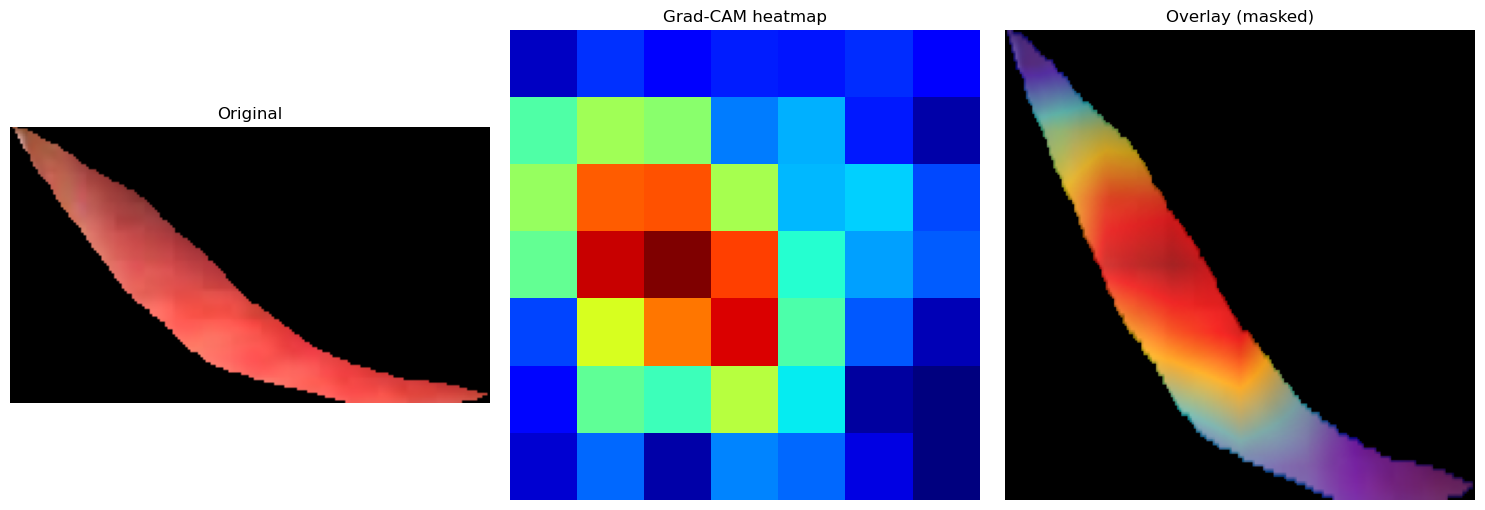

In [15]:
# Display results
plt.figure(figsize = (15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(conj_img_original, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(conj_heatmap, cmap = 'jet')
plt.title('Grad-CAM heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(conj_overlay, cv2.COLOR_BGR2RGB))
plt.title('Overlay (masked)')
plt.axis('off')
plt.tight_layout()

plt.savefig('fixed_conjunctiva_gradcam.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## 7. Nails Dataset - Grad-CAM Analysis
- In this section, we visualize how the model makes predictions on nails images.

In [17]:
nails_model = load_model('best_initial_model_nails.h5')

In [18]:
nail_img_path = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Nails\test\Anemic\nail_anemic_02542.jpg'

# Load and crop borders
nail_img_original = cv2.imread(nail_img_path)
nail_img_cropped = remove_black_borders(nail_img_original)
nail_img_resized = cv2.resize(nail_img_cropped, (224, 224))
nail_img_array = np.expand_dims(nail_img_resized / 255.0, axis = 0)

# Generate heatmap
nail_heatmap = get_gradcam_heatmap(nails_model, nail_img_array, last_conv_layer_name)

# Create masked overlay
nail_overlay = overlay_heatmap_masked(nail_img_resized, nail_heatmap)

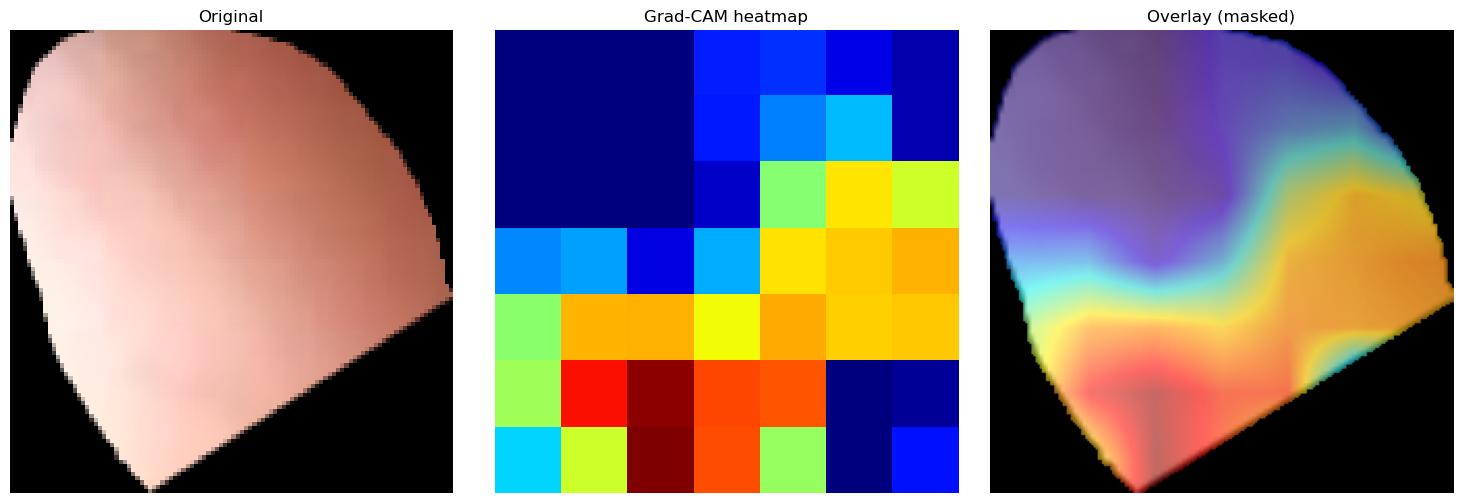

In [19]:
# Display results
plt.figure(figsize = (15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(nail_img_original, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(nail_heatmap, cmap = 'jet')
plt.title('Grad-CAM heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(nail_overlay, cv2.COLOR_BGR2RGB))
plt.title('Overlay (masked)')
plt.axis('off')
plt.tight_layout()

plt.savefig('fixed_nails_gradcam.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## 8. Interpretation and Comparison
- The Grad-CAM visualization for conjunctiva images shows that the model focuses primarily on the lower and central regions, where color variation and pallor are most evident. These regions are clinically relevant for anemia detection, indicating that the model is learning meaningful visual cues. Compared to earlier observations (before preprocessing), the attention is now more localized and less influenced by background areas, demonstrating the effectiveness of border removal and masking techniques.

- For nail images, the heatmaps are concentrated along the nail plate, suggesting that the model captures important features such as color and texture variations associated with anemia. In comparison to conjunctiva images, the attention in nail images appears more elongated and follows the structure of the nail, which reflects the anatomical differences between the two datasets.

- A comparison between the two datasets shows that both models successfully focus on relevant anatomical regions; however, conjunctiva images exhibit more concentrated attention zones, while nail images show broader activation patterns. This may be due to differences in feature distribution and visual complexity between the two types of images.

- Although Grad-CAM provides useful interpretability, the resulting heatmaps remain relatively coarse due to the low spatial resolution of the final convolutional layers in the model. Future improvements could include using higher-resolution feature maps, alternative explainability methods (e.g., Grad-CAM++), or incorporating segmentation techniques to further refine the localization of important regions.